# Proyek Akhir: Deteksi Dropout Siswa Jaya Jaya Institut

- Nama: Regina Maria Samantha George
- Email: reginageo22@gmail.com
- ID Dicoding: reregin

Notebook ini membangun dasar analisis untuk sistem peringatan dini
dropout. Semua angka dropout pada bagian EDA merupakan **outcome
historis**, bukan prediksi model.

## 1. Business Understanding

Jaya Jaya Institut menghadapi jumlah mahasiswa dropout yang tinggi.
Institusi ingin mengenali risiko sedini mungkin agar dukungan akademik,
administratif, dan finansial dapat diberikan sebelum mahasiswa keluar.

### Permasalahan bisnis

1. Berapa proporsi mahasiswa dengan status Dropout, Enrolled, dan Graduate?
2. Faktor akademik, administratif, finansial, dan program studi apa yang
   berkaitan dengan dropout?
3. Segmen mana yang layak diprioritaskan untuk dukungan?
4. Data apa yang tersedia pada checkpoint akhir semester pertama untuk
   membangun sistem peringatan dini yang dapat digunakan?

### Cakupan proyek

Proyek mencakup validasi data, preprocessing, EDA, analisis faktor,
rekomendasi action items, pemodelan tiga kelas, prototype Streamlit,
dan dashboard. Modeling akan membandingkan baseline saat pendaftaran
dengan model monitoring akhir semester pertama.

Target sumber memiliki tiga kelas: `Dropout`, `Enrolled`, dan `Graduate`.
Prototype kelak menampilkan ketiganya sekaligus menonjolkan probabilitas
Dropout untuk kebutuhan intervensi.

### Batasan interpretasi

Data bersifat observasional dan tidak memiliki dimensi waktu eksplisit.
Hubungan yang ditemukan disebut **asosiasi**, bukan bukti sebab-akibat.
Intervensi ditujukan untuk dukungan mahasiswa, bukan hukuman atau
pembatasan kesempatan.

## 2. Persiapan

### 2.1 Menyiapkan library dan konfigurasi

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_PATH = Path("data/data.csv")
PREPARED_PATH = Path("data/student_prepared.csv")
ASSOCIATION_PATH = Path("data/dropout_factor_association.csv")
PRIORITY_PATH = Path("data/dropout_priority_segments.csv")
COURSE_SUMMARY_PATH = Path("data/course_dropout_summary.csv")

STATUS_ORDER = ["Dropout", "Enrolled", "Graduate"]
STATUS_COLORS = {
    "Dropout": "#D1495B",
    "Enrolled": "#EDAE49",
    "Graduate": "#2A9D8F",
}

### 2.2 Memuat data sumber

In [2]:
raw_df = pd.read_csv(DATA_PATH, sep=";")
df = raw_df.copy()

print(f"Ukuran data                 : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Missing values              : {df.isna().sum().sum():,}")
print(f"Baris duplikat              : {df.duplicated().sum():,}")
print(f"Kelas target                : {sorted(df['Status'].unique())}")
display(df.head())

Ukuran data                 : 4,424 baris x 37 kolom
Missing values              : 0
Baris duplikat              : 0
Kelas target                : ['Dropout', 'Enrolled', 'Graduate']


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.000,1,19,12,5,9,127.300,1,0,0,1,1,0,20,0,0,0,0,0,0.000,0,0,0,0,0,0.000,0,10.800,1.400,1.740,Dropout
1,1,15,1,9254,1,1,160.000,1,1,3,3,3,142.500,1,0,0,0,1,0,19,0,0,6,6,6,14.000,0,0,6,6,6,13.667,0,13.900,-0.300,0.790,Graduate
2,1,1,5,9070,1,1,122.000,1,37,37,9,9,124.800,1,0,0,0,1,0,19,0,0,6,0,0,0.000,0,0,6,0,0,0.000,0,10.800,1.400,1.740,Dropout
3,1,17,2,9773,1,1,122.000,1,38,37,5,3,119.600,1,0,0,1,0,0,20,0,0,6,8,6,13.429,0,0,6,10,5,12.400,0,9.400,-0.800,-3.120,Graduate
4,2,39,1,8014,0,1,100.000,1,37,38,9,9,141.500,0,0,0,1,0,0,45,0,0,6,9,5,12.333,0,0,6,6,6,13.000,0,13.900,-0.300,0.790,Graduate


## 3. Data Understanding

Setiap baris merepresentasikan satu mahasiswa. Dataset tidak menyediakan
identifier, sehingga tahap preparation akan menambahkan `StudentId`
berurutan hanya sebagai surrogate key untuk penelusuran dan dashboard.
Identifier tersebut tidak akan menjadi feature model.

In [3]:
expected_columns = {
    "Marital_status", "Application_mode", "Application_order", "Course",
    "Daytime_evening_attendance", "Previous_qualification",
    "Previous_qualification_grade", "Nacionality", "Mothers_qualification",
    "Fathers_qualification", "Mothers_occupation", "Fathers_occupation",
    "Admission_grade", "Displaced", "Educational_special_needs", "Debtor",
    "Tuition_fees_up_to_date", "Gender", "Scholarship_holder",
    "Age_at_enrollment", "International",
    "Curricular_units_1st_sem_credited", "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations", "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_1st_sem_without_evaluations",
    "Curricular_units_2nd_sem_credited", "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations", "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
    "Curricular_units_2nd_sem_without_evaluations", "Unemployment_rate",
    "Inflation_rate", "GDP", "Status",
}

audit = {
    "expected_shape": df.shape == (4424, 37),
    "schema_matches": set(df.columns) == expected_columns,
    "target_valid": set(df["Status"]) == set(STATUS_ORDER),
    "no_missing_raw": not df.isna().any().any(),
    "no_duplicate_rows": not df.duplicated().any(),
    "all_numeric_finite": np.isfinite(df.select_dtypes(include="number")).all().all(),
    "first_sem_approved_not_above_enrolled": (
        df["Curricular_units_1st_sem_approved"]
        <= df["Curricular_units_1st_sem_enrolled"]
    ).all(),
    "second_sem_approved_not_above_enrolled": (
        df["Curricular_units_2nd_sem_approved"]
        <= df["Curricular_units_2nd_sem_enrolled"]
    ).all(),
}
audit_table = pd.DataFrame(
    {"check": audit.keys(), "passed": audit.values()}
)
display(audit_table)
assert audit_table["passed"].all(), "Data validation failed."

column_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
    "minimum": df.select_dtypes(include="number").min(),
    "maximum": df.select_dtypes(include="number").max(),
})
display(column_profile)

,check,passed
0,expected_shape,True
1,schema_matches,True
2,target_valid,True
3,no_missing_raw,True
4,no_duplicate_rows,True
5,all_numeric_finite,True
6,first_sem_approved_not_above_enrolled,True
7,second_sem_approved_not_above_enrolled,True


,dtype,missing,unique,minimum,maximum
Admission_grade,float64,0,620,95.000,190.000
Age_at_enrollment,int64,0,46,17.000,70.000
Application_mode,int64,0,18,1.000,57.000
Application_order,int64,0,8,0.000,9.000
Course,int64,0,17,33.000,"9,991.000"
Curricular_units_1st_sem_approved,int64,0,23,0.000,26.000
Curricular_units_1st_sem_credited,int64,0,21,0.000,20.000
Curricular_units_1st_sem_enrolled,int64,0,23,0.000,26.000
Curricular_units_1st_sem_evaluations,int64,0,35,0.000,45.000
Curricular_units_1st_sem_grade,float64,0,805,0.000,18.875


### 3.1 Distribusi outcome mahasiswa

,status,student_count,student_rate
0,Dropout,1421,32.1%
1,Enrolled,794,17.9%
2,Graduate,2209,49.9%


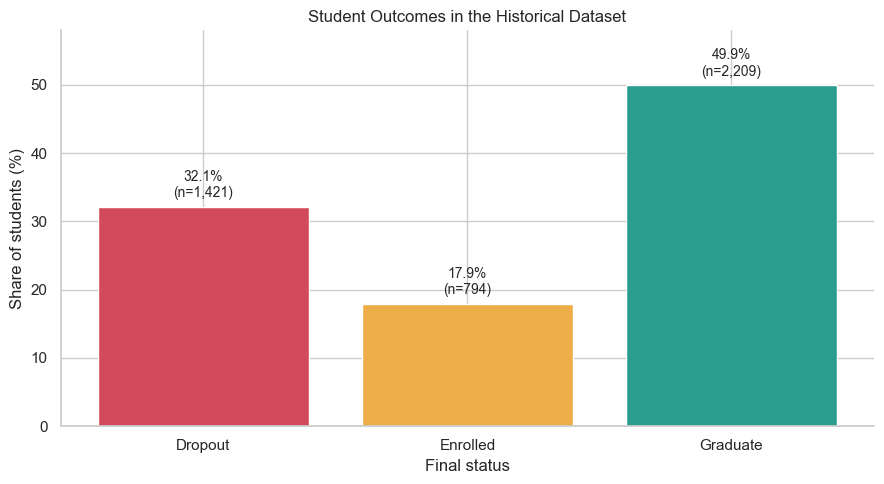

In [4]:
status_summary = (
    df["Status"].value_counts()
    .reindex(STATUS_ORDER)
    .rename_axis("status")
    .reset_index(name="student_count")
)
status_summary["student_rate"] = (
    status_summary["student_count"] / len(df)
)
display(status_summary.style.format({"student_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    status_summary["status"],
    status_summary["student_rate"] * 100,
    color=[STATUS_COLORS[value] for value in status_summary["status"]],
)
for bar, row in zip(bars, status_summary.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{row.student_rate:.1%}\n(n={row.student_count:,})",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set(
    title="Student Outcomes in the Historical Dataset",
    xlabel="Final status",
    ylabel="Share of students (%)",
    ylim=(0, 58),
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Terdapat **1.421 mahasiswa Dropout (32,1%)**, 794 Enrolled (18,0%),
dan 2.209 Graduate (49,9%). Karena kelas Enrolled lebih kecil, evaluasi
model kelak tidak boleh hanya mengandalkan accuracy; macro-F1 dan recall
per kelas harus ikut diperiksa.

## 4. Data Preparation / Preprocessing

Raw data tidak diubah. Prepared data menambahkan surrogate key, label
kategori yang dapat dibaca, dan indikator kemajuan semester pertama.
Missing engineered ratio untuk mahasiswa tanpa unit terdaftar dipertahankan
sebagai `NaN` dan diberi kategori eksplisit; nilai tersebut tidak diisi nol.

In [5]:
prepared_df = df.copy()
prepared_df.insert(0, "StudentId", np.arange(1, len(prepared_df) + 1))
prepared_df["IsDropout"] = prepared_df["Status"].eq("Dropout").astype(int)

marital_map = {
    1: "Single", 2: "Married", 3: "Widower", 4: "Divorced",
    5: "Facto union", 6: "Legally separated",
}
application_map = {
    1: "1st phase - general", 2: "Ordinance 612/93",
    5: "1st phase - Azores", 7: "Other higher course holders",
    10: "Ordinance 854-B/99", 15: "International bachelor",
    16: "1st phase - Madeira", 17: "2nd phase - general",
    18: "3rd phase - general", 26: "Different plan",
    27: "Other institution", 39: "Over 23 years old",
    42: "Transfer", 43: "Change of course",
    44: "Technological specialization", 51: "Change institution/course",
    53: "Short cycle diploma", 57: "International change institution/course",
}
course_map = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (evening)", 9003: "Agronomy",
    9070: "Communication Design", 9085: "Veterinary Nursing",
    9119: "Informatics Engineering", 9130: "Equinculture",
    9147: "Management", 9238: "Social Service", 9254: "Tourism",
    9500: "Nursing", 9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication", 9853: "Basic Education",
    9991: "Management (evening)",
}
previous_qualification_map = {
    1: "Secondary education", 2: "Bachelor degree", 3: "Degree",
    4: "Master", 5: "Doctorate", 6: "Higher education attendance",
    9: "12th year not completed", 10: "11th year not completed",
    12: "Other 11th year", 14: "10th year", 15: "10th year not completed",
    19: "Basic education 3rd cycle", 38: "Basic education 2nd cycle",
    39: "Technological specialization", 40: "Degree first cycle",
    42: "Professional higher technical", 43: "Master second cycle",
}
binary_maps = {
    "Daytime_evening_attendance": {1: "Daytime", 0: "Evening"},
    "Displaced": {1: "Yes", 0: "No"},
    "Educational_special_needs": {1: "Yes", 0: "No"},
    "Debtor": {1: "Yes", 0: "No"},
    "Tuition_fees_up_to_date": {1: "Up to date", 0: "Not up to date"},
    "Gender": {1: "Male", 0: "Female"},
    "Scholarship_holder": {1: "Yes", 0: "No"},
    "International": {1: "Yes", 0: "No"},
}

prepared_df["MaritalStatusLabel"] = prepared_df["Marital_status"].map(marital_map)
prepared_df["ApplicationModeLabel"] = prepared_df["Application_mode"].map(application_map)
prepared_df["CourseLabel"] = prepared_df["Course"].map(course_map)
prepared_df["PreviousQualificationLabel"] = prepared_df["Previous_qualification"].map(previous_qualification_map)
for source, mapping in binary_maps.items():
    prepared_df[f"{source}Label"] = prepared_df[source].map(mapping)

prepared_df["ApplicationChoiceGroup"] = pd.cut(
    prepared_df["Application_order"],
    bins=[-1, 0, 2, 5, 9],
    labels=["First choice", "2nd-3rd choice", "4th-6th choice", "7th-10th choice"],
)
prepared_df["AgeGroup"] = pd.cut(
    prepared_df["Age_at_enrollment"],
    bins=[16, 20, 24, 34, np.inf],
    labels=["17-20", "21-24", "25-34", "35+"],
)
prepared_df["AdmissionGradeBand"] = pd.cut(
    prepared_df["Admission_grade"],
    bins=[-np.inf, 120, 140, 160, np.inf],
    right=False,
    labels=["<120", "120-<140", "140-<160", "160+"],
)

first_enrolled = prepared_df["Curricular_units_1st_sem_enrolled"]
first_approved = prepared_df["Curricular_units_1st_sem_approved"]
prepared_df["FirstSemApprovalRate"] = np.where(
    first_enrolled.gt(0), first_approved / first_enrolled, np.nan
)
prepared_df["FirstSemApprovalBand"] = np.select(
    [
        first_enrolled.eq(0),
        prepared_df["FirstSemApprovalRate"].eq(0),
        prepared_df["FirstSemApprovalRate"].lt(0.5),
        prepared_df["FirstSemApprovalRate"].lt(0.8),
    ],
    ["No units enrolled", "0%", "1-<50%", "50-<80%"],
    default="80-100%",
)
first_grade = prepared_df["Curricular_units_1st_sem_grade"]
prepared_df["FirstSemGradeBand"] = np.select(
    [first_grade.eq(0), first_grade.lt(12),
     first_grade.lt(14), first_grade.lt(16)],
    ["No recorded grade", "Below 12", "12-<14", "14-<16"],
    default="16-20",
)

prepared_df.to_csv(PREPARED_PATH, index=False)

assert prepared_df["StudentId"].is_unique
assert prepared_df["CourseLabel"].notna().all()
assert prepared_df["ApplicationModeLabel"].notna().all()
assert prepared_df.loc[first_enrolled.eq(0), "FirstSemApprovalRate"].isna().all()

print(f"Prepared data : {prepared_df.shape[0]:,} rows x {prepared_df.shape[1]} columns")
print(f"Output        : {PREPARED_PATH}")
print(f"No-unit rows  : {first_enrolled.eq(0).sum():,}")

Prepared data : 4,424 rows x 57 columns
Output        : data\student_prepared.csv
No-unit rows  : 180


### 4.1 Feature availability dan guardrails model

Dua checkpoint akan dibandingkan pada tahap modeling:

- **Enrollment baseline:** informasi aplikasi, program, nilai masuk,
  perpindahan, serta status finansial yang tersedia saat pendaftaran.
- **First-semester monitoring:** baseline ditambah jumlah unit, evaluasi,
  approval, grade, dan unit tanpa evaluasi pada semester pertama.

Enam feature semester kedua dikeluarkan dari model operasional karena
tujuan bisnisnya adalah intervensi lebih dini. `StudentId` tidak digunakan
sebagai feature. Gender, nationality, marital status, age, international
status, special needs, pendidikan/pekerjaan orang tua, dan indikator
ekonomi makro tidak langsung digunakan sebagai dasar keputusan model;
variabel demografis dipertahankan untuk audit subgroup dan konteks EDA.

In [6]:
ENROLLMENT_MODEL_FEATURES = [
    "Application_mode", "Application_order", "Course",
    "Daytime_evening_attendance", "Previous_qualification",
    "Previous_qualification_grade", "Admission_grade", "Displaced",
    "Debtor", "Tuition_fees_up_to_date", "Scholarship_holder",
]
FIRST_SEMESTER_FEATURES = [
    "Curricular_units_1st_sem_credited",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_1st_sem_without_evaluations",
]
MONITORING_MODEL_FEATURES = ENROLLMENT_MODEL_FEATURES + FIRST_SEMESTER_FEATURES
SECOND_SEMESTER_FEATURES = [
    column for column in df.columns if "2nd_sem" in column
]

feature_policy = pd.DataFrame({
    "checkpoint": ["Enrollment baseline", "First-semester monitoring", "Excluded as later outcome"],
    "feature_count": [len(ENROLLMENT_MODEL_FEATURES), len(MONITORING_MODEL_FEATURES), len(SECOND_SEMESTER_FEATURES)],
    "features": [", ".join(ENROLLMENT_MODEL_FEATURES), ", ".join(MONITORING_MODEL_FEATURES), ", ".join(SECOND_SEMESTER_FEATURES)],
})
display(feature_policy)

,checkpoint,feature_count,features
0,Enrollment baseline,11,"Application_mode, Application_order, Course, D..."
1,First-semester monitoring,17,"Application_mode, Application_order, Course, D..."
2,Excluded as later outcome,6,"Curricular_units_2nd_sem_credited, Curricular_..."


## 5. Exploratory Data Analysis

In [7]:
def dropout_summary(frame, column, order=None):
    summary = (
        frame.groupby(column, observed=False)["IsDropout"]
        .agg(student_count="size", dropout_count="sum", dropout_rate="mean")
        .reset_index()
        .rename(columns={column: "segment"})
    )
    if order is not None:
        summary["segment"] = pd.Categorical(summary["segment"], categories=order, ordered=True)
        summary = summary.sort_values("segment")
    return summary.reset_index(drop=True)


def plot_dropout_rate(summary, ax, title, color="#D1495B"):
    plot_data = summary.copy()
    plot_data["segment"] = plot_data["segment"].astype(str)
    bars = ax.barh(
        plot_data["segment"], plot_data["dropout_rate"] * 100, color=color
    )
    for bar, row in zip(bars, plot_data.itertuples()):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{row.dropout_rate:.1%} (n={row.student_count:,})",
            va="center",
            fontsize=9,
        )
    ax.axvline(prepared_df["IsDropout"].mean() * 100, color="#495057", linestyle="--", linewidth=1.2)
    ax.set(title=title, xlabel="Historical dropout rate (%)", ylabel="")
    ax.set_xlim(0, max(100, plot_data["dropout_rate"].max() * 100 + 22))
    sns.despine(ax=ax)

### 5.1 Faktor administratif dan finansial

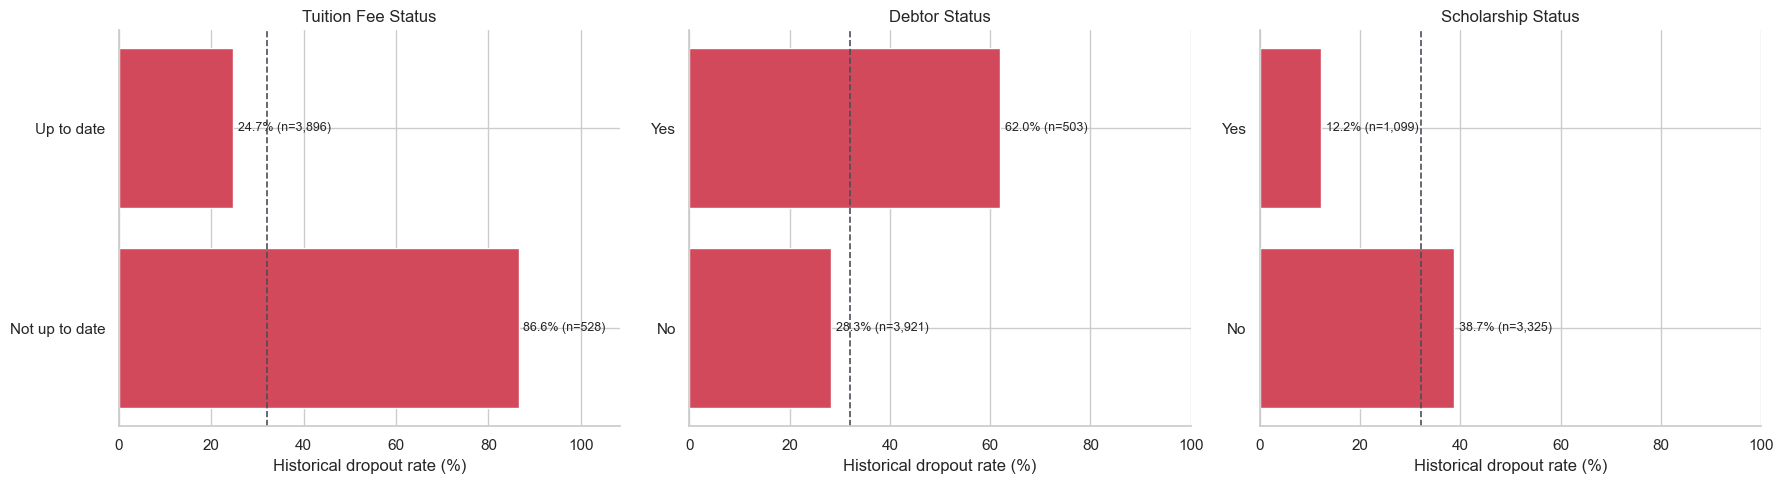

,factor,segment,student_count,dropout_count,dropout_rate
0,Tuition fee,Not up to date,528,457,0.866
1,Tuition fee,Up to date,3896,964,0.247
0,Debtor,No,3921,1109,0.283
1,Debtor,Yes,503,312,0.620
0,Scholarship,No,3325,1287,0.387
1,Scholarship,Yes,1099,134,0.122


In [8]:
tuition_summary = dropout_summary(prepared_df, "Tuition_fees_up_to_dateLabel")
debtor_summary = dropout_summary(prepared_df, "DebtorLabel")
scholarship_summary = dropout_summary(prepared_df, "Scholarship_holderLabel")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_dropout_rate(tuition_summary, axes[0], "Tuition Fee Status")
plot_dropout_rate(debtor_summary, axes[1], "Debtor Status")
plot_dropout_rate(scholarship_summary, axes[2], "Scholarship Status")
plt.tight_layout()
plt.show()

display(pd.concat({
    "Tuition fee": tuition_summary,
    "Debtor": debtor_summary,
    "Scholarship": scholarship_summary,
}, names=["factor"]).reset_index(level=0))

Status biaya kuliah merupakan sinyal administratif yang sangat kuat.
Mahasiswa dengan biaya kuliah tidak up to date memiliki dropout **86,6%**
(457 dari 528), dibandingkan 24,7% pada mahasiswa lainnya. Mahasiswa
berstatus debtor memiliki dropout **62,0%** (312 dari 503), dibandingkan
28,3% pada non-debtor. Hubungan ini mendukung bantuan dan outreach
finansial, bukan pembatasan layanan.

### 5.2 Kemajuan akademik semester pertama

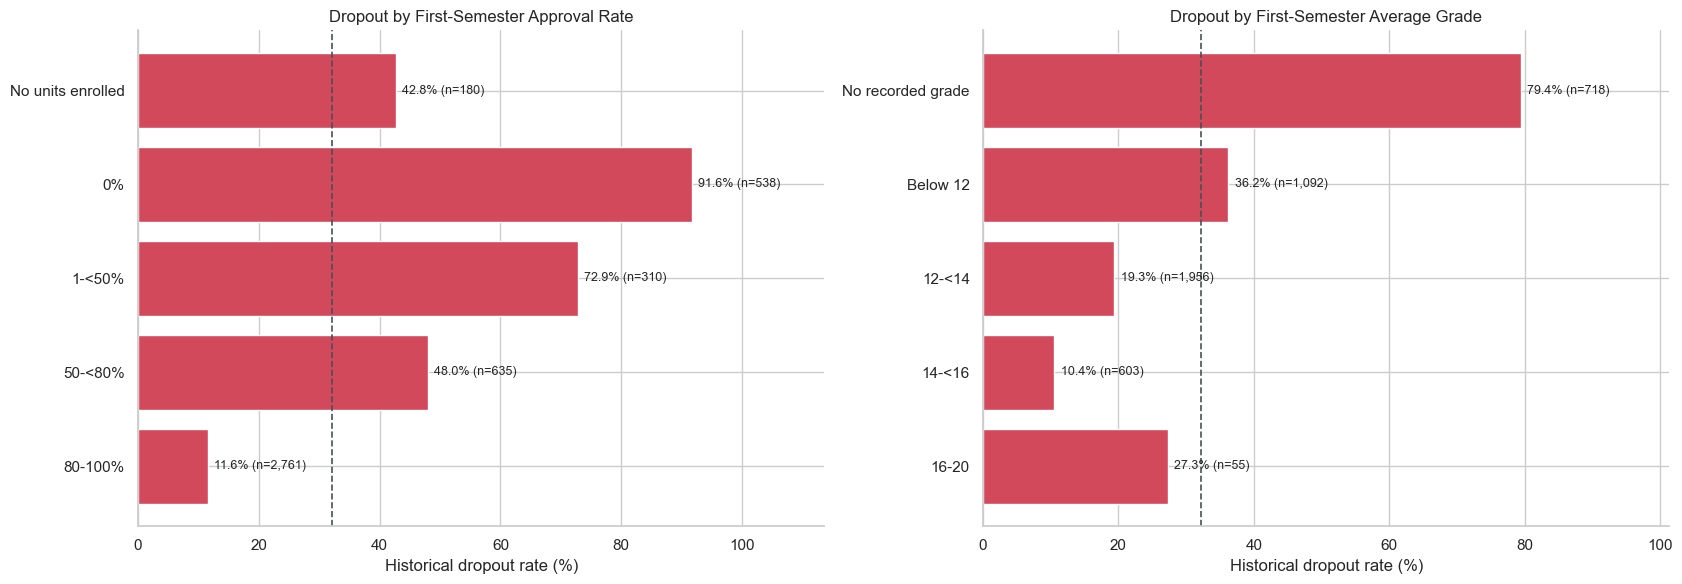

,segment,student_count,dropout_count,dropout_rate
0,No units enrolled,180,77,42.8%
1,0%,538,493,91.6%
2,1-<50%,310,226,72.9%
3,50-<80%,635,305,48.0%
4,80-100%,2761,320,11.6%


,segment,student_count,dropout_count,dropout_rate
0,No recorded grade,718,570,79.4%
1,Below 12,1092,395,36.2%
2,12-<14,1956,378,19.3%
3,14-<16,603,63,10.4%
4,16-20,55,15,27.3%


In [9]:
approval_order = ["No units enrolled", "0%", "1-<50%", "50-<80%", "80-100%"]
grade_order = ["No recorded grade", "Below 12", "12-<14", "14-<16", "16-20"]
approval_summary = dropout_summary(prepared_df, "FirstSemApprovalBand", approval_order)
grade_summary = dropout_summary(prepared_df, "FirstSemGradeBand", grade_order)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
plot_dropout_rate(approval_summary.iloc[::-1], axes[0], "Dropout by First-Semester Approval Rate")
plot_dropout_rate(grade_summary.iloc[::-1], axes[1], "Dropout by First-Semester Average Grade")
plt.tight_layout()
plt.show()

display(approval_summary.style.format({"dropout_rate": "{:.1%}"}))
display(grade_summary.style.format({"dropout_rate": "{:.1%}"}))

Kemajuan semester pertama memberikan sinyal intervensi yang lebih dekat
dengan perilaku akademik. Mahasiswa yang mengambil unit tetapi menyetujui
kurang dari 50% memiliki dropout **84,8%** (719 dari 848), dibandingkan
19,6% pada mahasiswa lainnya. Sebanyak 718 mahasiswa tidak menyelesaikan
satu pun unit pada semester pertama; dropout kelompok ini mencapai
**79,4%**. Segmen saling tumpang tindih dan tidak boleh dijumlahkan.

### 5.3 Program studi dan konteks mahasiswa

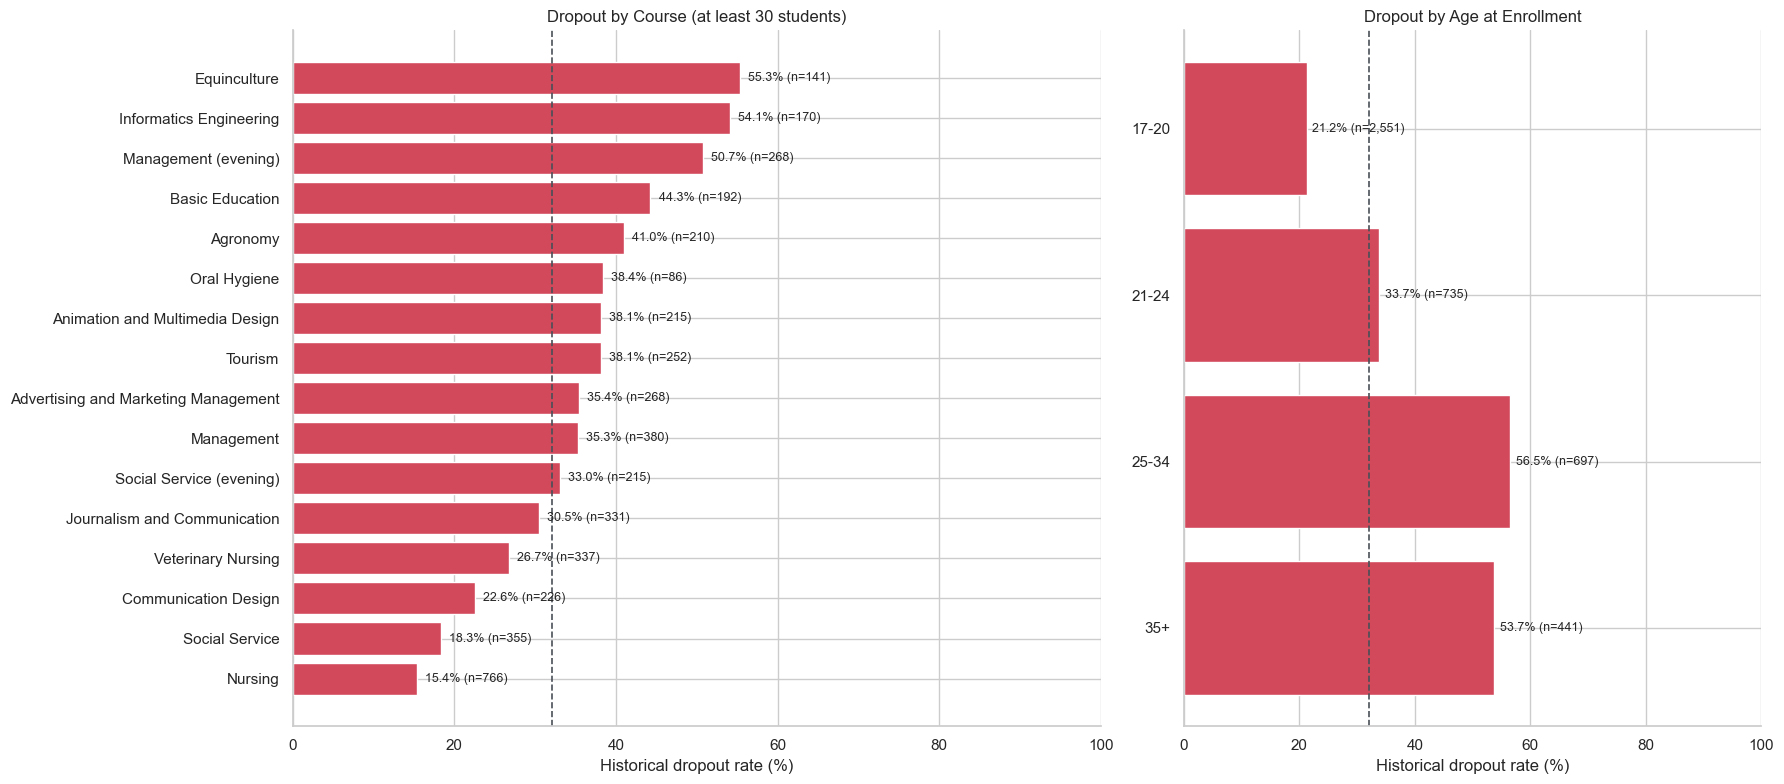

,segment,student_count,dropout_count,dropout_rate
4,Biofuel Production Technologies,12,8,66.7%
6,Equinculture,141,78,55.3%
7,Informatics Engineering,170,92,54.1%
10,Management (evening),268,136,50.7%
3,Basic Education,192,85,44.3%
1,Agronomy,210,86,41.0%
12,Oral Hygiene,86,33,38.4%
2,Animation and Multimedia Design,215,82,38.1%
15,Tourism,252,96,38.1%
0,Advertising and Marketing Management,268,95,35.4%


,segment,student_count,dropout_count,dropout_rate
0,Daytime,3941,1214,30.8%
1,Evening,483,207,42.9%


In [10]:
course_summary = dropout_summary(prepared_df, "CourseLabel")
course_summary = course_summary.sort_values("dropout_rate", ascending=False)
course_summary.to_csv(COURSE_SUMMARY_PATH, index=False)

course_plot = course_summary.query("student_count >= 30").copy()
age_summary = dropout_summary(prepared_df, "AgeGroup", ["17-20", "21-24", "25-34", "35+"])
attendance_summary = dropout_summary(prepared_df, "Daytime_evening_attendanceLabel")

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.4, 1]})
plot_dropout_rate(course_plot.iloc[::-1], axes[0], "Dropout by Course (at least 30 students)")
plot_dropout_rate(age_summary.iloc[::-1], axes[1], "Dropout by Age at Enrollment")
plt.tight_layout()
plt.show()

display(course_summary.style.format({"dropout_rate": "{:.1%}"}))
display(attendance_summary.style.format({"dropout_rate": "{:.1%}"}))

Di antara program dengan minimal 30 mahasiswa, dropout tertinggi terdapat
pada Equinculture (**55,3%**, 78 dari 141), Informatics Engineering
(**54,1%**, 92 dari 170), dan Management evening (**50,7%**, 136 dari
268). Program Biofuel memiliki 12 mahasiswa sehingga rate-nya tidak
digunakan sebagai prioritas tanpa bukti tambahan.

Mahasiswa berusia 35+ memiliki dropout 53,7%, tetapi usia dapat berkaitan
dengan pekerjaan, tanggung jawab keluarga, mode kehadiran, dan faktor
lain yang tidak tersedia. Usia dipakai sebagai konteks untuk merancang
layanan fleksibel dan audit fairness, bukan sebagai alasan membatasi akses.

## 6. Analisis Asosiasi dan Priority Segments

In [11]:
def corrected_cramers_v(frame, factor, target="IsDropout"):
    table = pd.crosstab(frame[factor], frame[target])
    chi2, p_value, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    rows, cols = table.shape
    phi2 = chi2 / n
    phi2_corrected = max(0, phi2 - ((cols - 1) * (rows - 1)) / (n - 1))
    rows_corrected = rows - ((rows - 1) ** 2) / (n - 1)
    cols_corrected = cols - ((cols - 1) ** 2) / (n - 1)
    denominator = min(cols_corrected - 1, rows_corrected - 1)
    value = np.sqrt(phi2_corrected / denominator) if denominator > 0 else 0
    return value, p_value, int(table.sum(axis=1).min()), rows


association_factors = {
    "First-semester approval band": "FirstSemApprovalBand",
    "First-semester grade band": "FirstSemGradeBand",
    "Tuition fee status": "Tuition_fees_up_to_dateLabel",
    "Course": "CourseLabel",
    "Application mode": "ApplicationModeLabel",
    "Age group": "AgeGroup",
    "Debtor status": "DebtorLabel",
    "Scholarship status": "Scholarship_holderLabel",
    "Previous qualification": "PreviousQualificationLabel",
    "Attendance schedule": "Daytime_evening_attendanceLabel",
    "Application choice": "ApplicationChoiceGroup",
    "Displaced": "DisplacedLabel",
    "Gender (audit context)": "GenderLabel",
    "International (audit context)": "InternationalLabel",
    "Marital status (audit context)": "MaritalStatusLabel",
}

association_rows = []
for factor_name, column in association_factors.items():
    value, p_value, minimum_group, group_count = corrected_cramers_v(prepared_df, column)
    association_rows.append({
        "factor": factor_name,
        "column": column,
        "corrected_cramers_v": value,
        "p_value": p_value,
        "group_count": group_count,
        "minimum_group_size": minimum_group,
    })

association_df = pd.DataFrame(association_rows)
p_values = association_df["p_value"].to_numpy()
sort_index = np.argsort(p_values)
ranked_q = p_values[sort_index] * len(p_values) / np.arange(1, len(p_values) + 1)
ranked_q = np.minimum.accumulate(ranked_q[::-1])[::-1]
q_values = np.empty_like(ranked_q)
q_values[sort_index] = np.clip(ranked_q, 0, 1)
association_df["fdr_q_value"] = q_values
association_df["significant_fdr_5pct"] = association_df["fdr_q_value"] < 0.05
association_df = association_df.sort_values("corrected_cramers_v", ascending=False)
association_df.to_csv(ASSOCIATION_PATH, index=False)

display(association_df.style.format({
    "corrected_cramers_v": "{:.3f}",
    "p_value": "{:.3g}",
    "fdr_q_value": "{:.3g}",
}))

,factor,column,corrected_cramers_v,p_value,group_count,minimum_group_size,fdr_q_value,significant_fdr_5pct
0,First-semester approval band,FirstSemApprovalBand,0.624,0,5,180,0,True
1,First-semester grade band,FirstSemGradeBand,0.480,8.55e-220,5,55,6.41e-219,True
2,Tuition fee status,Tuition_fees_up_to_dateLabel,0.428,1.37e-178,2,528,6.87e-178,True
5,Age group,AgeGroup,0.309,1.25e-91,4,441,4.7e-91,True
4,Application mode,ApplicationModeLabel,0.294,2.84e-74,18,1,8.51e-74,True
3,Course,CourseLabel,0.253,5.83e-54,17,12,1.25e-53,True
7,Scholarship status,Scholarship_holderLabel,0.244,1.32e-59,2,1099,3.31e-59,True
6,Debtor status,DebtorLabel,0.228,3.13e-52,2,503,5.88e-52,True
8,Previous qualification,PreviousQualificationLabel,0.205,2.34e-34,17,1,3.52e-34,True
12,Gender (audit context),GenderLabel,0.203,9.88e-42,2,1556,1.65e-41,True


In [12]:
def wilson_interval(successes, total, z=1.96):
    probability = successes / total
    denominator = 1 + z**2 / total
    center = (probability + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt(
        probability * (1 - probability) / total + z**2 / (4 * total**2)
    ) / denominator
    return center - margin, center + margin


priority_specs = [
    ("Academic progress", "First-semester approval below 50%",
     prepared_df["Curricular_units_1st_sem_enrolled"].gt(0)
     & prepared_df["FirstSemApprovalRate"].lt(0.5)),
    ("Academic progress", "No first-semester approved units",
     prepared_df["Curricular_units_1st_sem_approved"].eq(0)),
    ("Administration", "Tuition fees not up to date",
     prepared_df["Tuition_fees_up_to_date"].eq(0)),
    ("Financial", "Debtor",
     prepared_df["Debtor"].eq(1)),
    ("Financial", "No scholarship",
     prepared_df["Scholarship_holder"].eq(0)),
    ("Schedule", "Evening attendance",
     prepared_df["Daytime_evening_attendance"].eq(0)),
    ("Course", "Equinculture",
     prepared_df["Course"].eq(9130)),
    ("Course", "Informatics Engineering",
     prepared_df["Course"].eq(9119)),
    ("Course", "Management (evening)",
     prepared_df["Course"].eq(9991)),
    ("Context only", "Age at enrollment 35+",
     prepared_df["Age_at_enrollment"].ge(35)),
]

priority_rows = []
for category, segment, mask in priority_specs:
    total = int(mask.sum())
    cases = int(prepared_df.loc[mask, "IsDropout"].sum())
    reference_total = int((~mask).sum())
    reference_cases = int(prepared_df.loc[~mask, "IsDropout"].sum())
    rate = cases / total
    reference_rate = reference_cases / reference_total
    lower, upper = wilson_interval(cases, total)
    priority_rows.append({
        "category": category,
        "segment": segment,
        "student_count": total,
        "dropout_count": cases,
        "dropout_rate": rate,
        "reference_dropout_rate": reference_rate,
        "descriptive_risk_ratio": rate / reference_rate,
        "wilson_95pct_lower": lower,
        "wilson_95pct_upper": upper,
    })

priority_df = pd.DataFrame(priority_rows).sort_values(
    ["dropout_rate", "student_count"], ascending=[False, False]
)
priority_df.to_csv(PRIORITY_PATH, index=False)
display(priority_df.style.format({
    "dropout_rate": "{:.1%}",
    "reference_dropout_rate": "{:.1%}",
    "descriptive_risk_ratio": "{:.2f}x",
    "wilson_95pct_lower": "{:.1%}",
    "wilson_95pct_upper": "{:.1%}",
}))

,category,segment,student_count,dropout_count,dropout_rate,reference_dropout_rate,descriptive_risk_ratio,wilson_95pct_lower,wilson_95pct_upper
2,Administration,Tuition fees not up to date,528,457,86.6%,24.7%,3.50x,83.4%,89.2%
0,Academic progress,First-semester approval below 50%,848,719,84.8%,19.6%,4.32x,82.2%,87.0%
1,Academic progress,No first-semester approved units,718,570,79.4%,23.0%,3.46x,76.3%,82.2%
3,Financial,Debtor,503,312,62.0%,28.3%,2.19x,57.7%,66.2%
6,Course,Equinculture,141,78,55.3%,31.4%,1.76x,47.1%,63.3%
7,Course,Informatics Engineering,170,92,54.1%,31.2%,1.73x,46.6%,61.4%
9,Context only,Age at enrollment 35+,441,237,53.7%,29.7%,1.81x,49.1%,58.3%
8,Course,Management (evening),268,136,50.7%,30.9%,1.64x,44.8%,56.7%
5,Schedule,Evening attendance,483,207,42.9%,30.8%,1.39x,38.5%,47.3%
4,Financial,No scholarship,3325,1287,38.7%,12.2%,3.17x,37.1%,40.4%


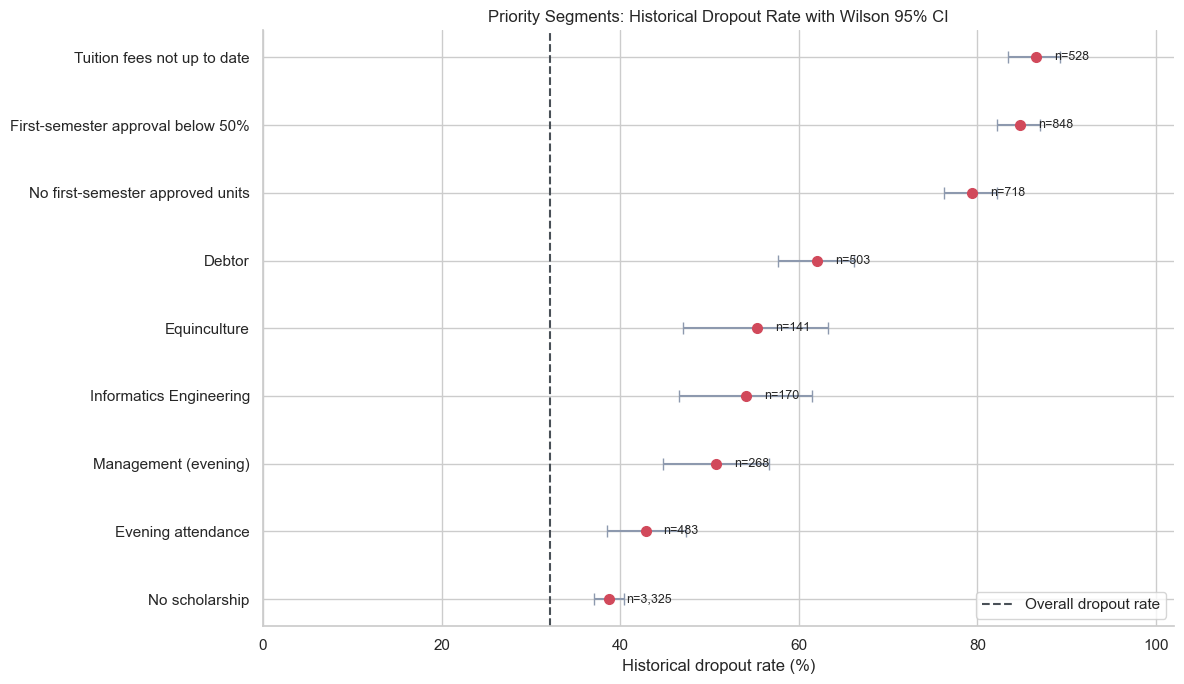

In [13]:
plot_data = priority_df.loc[priority_df["category"] != "Context only"].copy()
plot_data = plot_data.sort_values("dropout_rate")
x_error = np.vstack([
    plot_data["dropout_rate"] - plot_data["wilson_95pct_lower"],
    plot_data["wilson_95pct_upper"] - plot_data["dropout_rate"],
])

fig, ax = plt.subplots(figsize=(12, 7))
ax.errorbar(
    plot_data["dropout_rate"] * 100,
    plot_data["segment"],
    xerr=x_error * 100,
    fmt="o",
    color="#D1495B",
    ecolor="#8D99AE",
    capsize=4,
    markersize=7,
)
ax.axvline(prepared_df["IsDropout"].mean() * 100, color="#495057", linestyle="--", label="Overall dropout rate")
for row_index, row in enumerate(plot_data.itertuples()):
    ax.text(row.dropout_rate * 100 + 2, row_index, f"n={row.student_count:,}", va="center", fontsize=9)
ax.set(
    title="Priority Segments: Historical Dropout Rate with Wilson 95% CI",
    xlabel="Historical dropout rate (%)",
    ylabel="",
    xlim=(0, 102),
)
ax.legend(loc="lower right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 7. Temuan Bisnis

1. **Dropout merupakan masalah besar.** Sebanyak 1.421 dari 4.424
   mahasiswa (32,1%) berstatus Dropout.
2. **Kemajuan akademik semester pertama memberi sinyal paling langsung.**
   Approval di bawah 50% berkaitan dengan dropout 84,8%, sementara tidak
   ada unit yang disetujui berkaitan dengan dropout 79,4%.
3. **Masalah administrasi dan finansial membutuhkan respons cepat.**
   Tuition fee tidak up to date berkaitan dengan dropout 86,6%; debtor
   dengan 62,0%. Kedua segmen dapat bertumpang tindih.
4. **Risiko berbeda menurut program.** Equinculture, Informatics
   Engineering, dan Management evening berada di atas 50% dropout dan
   memiliki jumlah mahasiswa yang cukup untuk dipantau. Biofuel tidak
   diprioritaskan hanya dari rate karena ukuran kelompoknya 12.
5. **Jadwal dan kebutuhan mahasiswa perlu dipahami.** Evening attendance
   memiliki dropout 42,9% dibandingkan 30,8% pada daytime. Usia 35+
   juga lebih tinggi, tetapi demografi hanya menjadi konteks layanan dan
   audit, bukan dasar tindakan yang merugikan.

Semua perbandingan di atas bersifat deskriptif. Segmen dapat saling
tumpang tindih, sehingga jumlah kasus atau estimasi dampaknya tidak boleh
dijumlahkan begitu saja.

## 8. Rekomendasi Action Items

1. **Buat early-alert mingguan setelah hasil semester pertama tersedia.**
   Prioritaskan mahasiswa dengan approval di bawah 50%, tidak ada unit
   approved, atau grade sangat rendah untuk outreach manusia.
2. **Hubungi mahasiswa dengan tunggakan secara proaktif.** Tawarkan
   konseling pembayaran, cicilan, bantuan darurat, atau rujukan beasiswa.
   Jangan memblokir dukungan hanya karena model atau status debtor.
3. **Bangun program recovery akademik.** Sediakan tutoring, study plan,
   konsultasi dosen wali, dan evaluasi ulang beban studi bagi mahasiswa
   dengan kemajuan semester pertama rendah.
4. **Lakukan review program pada tiga course prioritas.** Analisis mata
   kuliah penghambat, jadwal, kapasitas bimbingan, dan alasan keluar di
   Equinculture, Informatics Engineering, dan Management evening.
5. **Sesuaikan layanan untuk mahasiswa evening dan non-tradisional.**
   Sediakan jam konsultasi fleksibel, dukungan daring, dan penjadwalan
   yang mempertimbangkan pekerjaan atau tanggung jawab keluarga.
6. **Uji intervensi secara terukur.** Catat tanggal alert, jenis bantuan,
   penerimaan bantuan, dan outcome berikutnya. Bandingkan cohort atau
   gunakan pilot bertahap untuk menilai dampak.
7. **Terapkan guardrails.** Prediksi hanya memprioritaskan tawaran bantuan.
   Jangan gunakan gender, nationality, usia, marital status, disability,
   atau probabilitas model untuk sanksi, penolakan, atau pengurangan hak.
   Audit recall dan false-positive rate per subgroup sebelum deployment.

## 9. Status Phase 2-3

Data understanding, preprocessing, EDA, analisis asosiasi, temuan bisnis,
dan action items telah selesai. Artifact berikut telah diekspor:

- `data/student_prepared.csv`
- `data/dropout_factor_association.csv`
- `data/dropout_priority_segments.csv`
- `data/course_dropout_summary.csv`

Tahap selanjutnya adalah modeling. Data split, preprocessing pipeline,
model comparison, threshold/calibration, dan final holdout evaluation
belum dilakukan pada checkpoint ini.

## 10. Modeling

Modeling mempertahankan tiga kelas sumber. Data dibagi secara stratified
menjadi 80% development dan 20% untouched holdout. Seluruh preprocessing
berada di dalam pipeline. Model dan checkpoint dipilih hanya dari
cross-validation pada development set.

Untuk kebutuhan outreach, threshold Dropout terpisah dioptimalkan dengan
F2 pada out-of-fold probability development set. F2 memberi bobot lebih
besar pada recall agar mahasiswa berisiko tidak mudah terlewat, dengan
konsekuensi false positive yang harus ditinjau manusia.

In [14]:
import json
import platform

import joblib
import sklearn
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, log_loss, precision_recall_curve,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "student_status_model.joblib"
METADATA_PATH = MODEL_DIR / "model_metadata.json"
COMPARISON_PATH = MODEL_DIR / "model_comparison.csv"
HOLDOUT_METRICS_PATH = MODEL_DIR / "holdout_metrics.json"
CONFUSION_PATH = MODEL_DIR / "holdout_confusion_matrix.csv"
THRESHOLD_PATH = MODEL_DIR / "dropout_threshold_metrics.csv"
IMPORTANCE_PATH = MODEL_DIR / "permutation_importance.csv"
SUBGROUP_PATH = MODEL_DIR / "subgroup_audit.csv"
PREDICTION_SAMPLE_PATH = Path("data/prediction_sample.csv")

CLASS_ORDER = ["Dropout", "Enrolled", "Graduate"]
X_all = df.drop(columns="Status")
y_all = df["Status"]
train_index, test_index = train_test_split(
    np.arange(len(df)), test_size=0.20, random_state=RANDOM_STATE,
    stratify=y_all,
)
y_train = y_all.iloc[train_index]
y_test = y_all.iloc[test_index]

print(f"Development rows : {len(train_index):,}")
print(f"Holdout rows     : {len(test_index):,}")
print("Holdout distribution:")
display(y_test.value_counts().reindex(CLASS_ORDER).to_frame("student_count"))

Development rows : 3,539
Holdout rows     : 885
Holdout distribution:


,student_count
Status,
Dropout,284
Enrolled,159
Graduate,442


In [15]:
categorical_candidates = {
    "Application_mode", "Course", "Daytime_evening_attendance",
    "Previous_qualification", "Displaced", "Debtor",
    "Tuition_fees_up_to_date", "Scholarship_holder",
}


def build_pipeline(features, estimator):
    categorical = [column for column in features if column in categorical_candidates]
    numeric = [column for column in features if column not in categorical]
    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
            ("numeric", StandardScaler(), numeric),
        ],
        remainder="drop",
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", estimator),
    ])


checkpoints = {
    "Enrollment baseline": ENROLLMENT_MODEL_FEATURES,
    "First-semester monitoring": MONITORING_MODEL_FEATURES,
}
estimators = {
    "Class-weighted logistic regression": LogisticRegression(
        class_weight="balanced", max_iter=3000, solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "Balanced random forest": RandomForestClassifier(
        n_estimators=500, min_samples_leaf=3, max_features="sqrt",
        class_weight="balanced_subsample", random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "dropout_recall": sklearn.metrics.make_scorer(
        recall_score, labels=["Dropout"], average="macro", zero_division=0
    ),
}

comparison_rows = []
candidate_pipelines = {}
for checkpoint_name, features in checkpoints.items():
    for model_name, estimator in estimators.items():
        pipeline = build_pipeline(features, clone(estimator))
        scores = cross_validate(
            pipeline,
            X_all.iloc[train_index][features],
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
        )
        key = f"{checkpoint_name} | {model_name}"
        candidate_pipelines[key] = pipeline
        comparison_rows.append({
            "candidate": key,
            "checkpoint": checkpoint_name,
            "model": model_name,
            "feature_count": len(features),
            "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
            "cv_macro_f1_std": scores["test_macro_f1"].std(ddof=1),
            "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
            "cv_dropout_recall_mean": scores["test_dropout_recall"].mean(),
        })

model_comparison = pd.DataFrame(comparison_rows).sort_values(
    ["cv_macro_f1_mean", "cv_dropout_recall_mean"], ascending=False
).reset_index(drop=True)
model_comparison.to_csv(COMPARISON_PATH, index=False)
best_key = model_comparison.loc[0, "candidate"]
best_checkpoint = model_comparison.loc[0, "checkpoint"]
best_model_name = model_comparison.loc[0, "model"]
selected_features = checkpoints[best_checkpoint]
selected_pipeline = candidate_pipelines[best_key]

display(model_comparison.style.format({
    "cv_macro_f1_mean": "{:.3f}", "cv_macro_f1_std": "{:.3f}",
    "cv_balanced_accuracy_mean": "{:.3f}",
    "cv_dropout_recall_mean": "{:.3f}",
}))
print(f"Selected candidate: {best_key}")

,candidate,checkpoint,model,feature_count,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean,cv_dropout_recall_mean
0,First-semester monitoring | Balanced random forest,First-semester monitoring,Balanced random forest,17,0.683,0.031,0.681,0.704
1,First-semester monitoring | Class-weighted logistic regression,First-semester monitoring,Class-weighted logistic regression,17,0.679,0.023,0.686,0.688
2,Enrollment baseline | Balanced random forest,Enrollment baseline,Balanced random forest,11,0.556,0.011,0.557,0.566
3,Enrollment baseline | Class-weighted logistic regression,Enrollment baseline,Class-weighted logistic regression,11,0.548,0.015,0.556,0.530


Selected candidate: First-semester monitoring | Balanced random forest


### 10.1 Calibration dan threshold screening Dropout

Model terpilih dikalibrasi dengan sigmoid dan internal 3-fold CV.
Out-of-fold probabilities untuk threshold tuning tidak menggunakan
holdout. Threshold screening tidak mengganti prediksi status tiga kelas;
keduanya dilaporkan sebagai output berbeda.

In [16]:
calibrated_template = CalibratedClassifierCV(
    estimator=clone(selected_pipeline), method="sigmoid", cv=3, n_jobs=-1
)
X_train_selected = X_all.iloc[train_index][selected_features]
X_test_selected = X_all.iloc[test_index][selected_features]

oof_probabilities = cross_val_predict(
    calibrated_template,
    X_train_selected,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)
oof_classes = sorted(y_train.unique())
dropout_index_oof = oof_classes.index("Dropout")
oof_dropout_probability = oof_probabilities[:, dropout_index_oof]
y_train_dropout = y_train.eq("Dropout").astype(int).to_numpy()

threshold_precision, threshold_recall, thresholds = precision_recall_curve(
    y_train_dropout, oof_dropout_probability
)
valid_precision = threshold_precision[:-1]
valid_recall = threshold_recall[:-1]
f2_values = np.divide(
    5 * valid_precision * valid_recall,
    4 * valid_precision + valid_recall,
    out=np.zeros_like(valid_precision),
    where=(4 * valid_precision + valid_recall) > 0,
)
best_threshold_index = int(np.argmax(f2_values))
dropout_threshold = float(thresholds[best_threshold_index])

calibrated_model = clone(calibrated_template)
calibrated_model.fit(X_train_selected, y_train)
test_probabilities = calibrated_model.predict_proba(X_test_selected)
model_classes = list(calibrated_model.classes_)
dropout_class_index = model_classes.index("Dropout")
test_dropout_probability = test_probabilities[:, dropout_class_index]

print(f"Selected checkpoint : {best_checkpoint}")
print(f"Selected model      : {best_model_name}")
print(f"Dropout threshold   : {dropout_threshold:.6f}")
print(f"OOF precision       : {valid_precision[best_threshold_index]:.3f}")
print(f"OOF recall          : {valid_recall[best_threshold_index]:.3f}")
print(f"OOF F2              : {f2_values[best_threshold_index]:.3f}")

Selected checkpoint : First-semester monitoring
Selected model      : Balanced random forest
Dropout threshold   : 0.146906
OOF precision       : 0.555
OOF recall          : 0.899
OOF F2              : 0.800


## 11. Evaluation

In [17]:
test_prediction = calibrated_model.predict(X_test_selected)
y_test_binary = y_test.eq("Dropout").astype(int).to_numpy()
test_alert = (test_dropout_probability >= dropout_threshold).astype(int)
screening_cm = confusion_matrix(y_test_binary, test_alert, labels=[0, 1])
tn, fp, fn, tp = screening_cm.ravel()
one_hot_test = label_binarize(y_test, classes=model_classes)

holdout_metrics = {
    "accuracy": accuracy_score(y_test, test_prediction),
    "macro_f1": f1_score(y_test, test_prediction, average="macro"),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
    "macro_roc_auc_ovr": roc_auc_score(
        y_test, test_probabilities, labels=model_classes,
        multi_class="ovr", average="macro"
    ),
    "multiclass_log_loss": log_loss(y_test, test_probabilities, labels=model_classes),
    "multiclass_brier_score": np.mean(
        np.sum((test_probabilities - one_hot_test) ** 2, axis=1)
    ),
    "dropout_class_recall_argmax": recall_score(
        y_test, test_prediction, labels=["Dropout"], average="macro"
    ),
    "dropout_class_precision_argmax": precision_score(
        y_test, test_prediction, labels=["Dropout"], average="macro"
    ),
    "dropout_screening_threshold": dropout_threshold,
    "dropout_screening_recall": recall_score(y_test_binary, test_alert),
    "dropout_screening_precision": precision_score(y_test_binary, test_alert),
    "dropout_screening_f2": (
        5 * precision_score(y_test_binary, test_alert) * recall_score(y_test_binary, test_alert)
        / (4 * precision_score(y_test_binary, test_alert) + recall_score(y_test_binary, test_alert))
    ),
    "dropout_screening_specificity": tn / (tn + fp),
    "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
}

with HOLDOUT_METRICS_PATH.open("w", encoding="utf-8") as handle:
    json.dump(holdout_metrics, handle, indent=2)

report = pd.DataFrame(
    classification_report(
        y_test, test_prediction, labels=CLASS_ORDER,
        output_dict=True, zero_division=0
    )
).T
holdout_cm = pd.DataFrame(
    confusion_matrix(y_test, test_prediction, labels=CLASS_ORDER),
    index=[f"Actual {label}" for label in CLASS_ORDER],
    columns=[f"Predicted {label}" for label in CLASS_ORDER],
)
holdout_cm.to_csv(CONFUSION_PATH)
threshold_metrics = pd.DataFrame([{
    "threshold": dropout_threshold,
    "precision": holdout_metrics["dropout_screening_precision"],
    "recall": holdout_metrics["dropout_screening_recall"],
    "f2": holdout_metrics["dropout_screening_f2"],
    "specificity": holdout_metrics["dropout_screening_specificity"],
    "tn": tn, "fp": fp, "fn": fn, "tp": tp,
}])
threshold_metrics.to_csv(THRESHOLD_PATH, index=False)

display(pd.Series(holdout_metrics, name="value").to_frame())
display(report.style.format("{:.3f}"))
display(holdout_cm)

,value
accuracy,0.720
macro_f1,0.634
balanced_accuracy,0.630
macro_roc_auc_ovr,0.856
multiclass_log_loss,0.660
multiclass_brier_score,0.372
dropout_class_recall_argmax,0.704
dropout_class_precision_argmax,0.738
dropout_screening_threshold,0.147
dropout_screening_recall,0.905


,precision,recall,f1-score,support
Dropout,0.738,0.704,0.721,284.000
Enrolled,0.415,0.308,0.354,159.000
Graduate,0.782,0.878,0.827,442.000
accuracy,0.720,0.720,0.720,0.720
macro avg,0.645,0.630,0.634,885.000
weighted avg,0.702,0.720,0.708,885.000


,Predicted Dropout,Predicted Enrolled,Predicted Graduate
Actual Dropout,200,36,48
Actual Enrolled,50,49,60
Actual Graduate,21,33,388


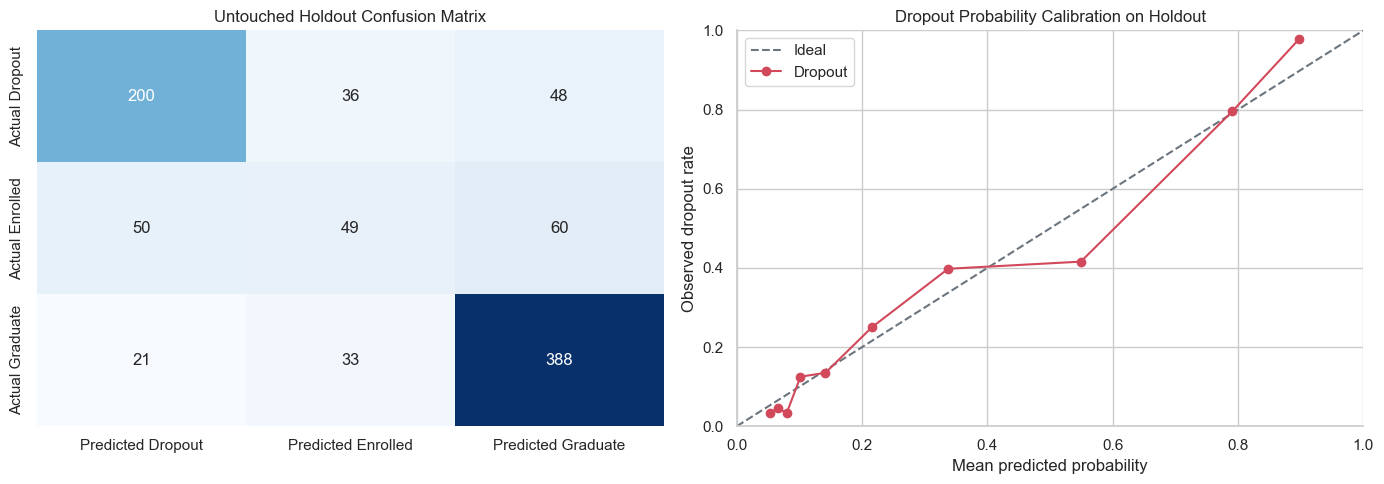

In [18]:
probability_true, probability_predicted = calibration_curve(
    y_test_binary, test_dropout_probability, n_bins=10, strategy="quantile"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    holdout_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0]
)
axes[0].set_title("Untouched Holdout Confusion Matrix")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="#6C757D", label="Ideal")
axes[1].plot(probability_predicted, probability_true, marker="o", color="#D1495B", label="Dropout")
axes[1].set(
    title="Dropout Probability Calibration on Holdout",
    xlabel="Mean predicted probability",
    ylabel="Observed dropout rate",
    xlim=(0, 1), ylim=(0, 1),
)
axes[1].legend()
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

### 11.1 Permutation importance dan subgroup audit

,feature,importance_mean,importance_std
14,Curricular_units_1st_sem_approved,0.1033,0.0130
9,Tuition_fees_up_to_date,0.0485,0.0073
15,Curricular_units_1st_sem_grade,0.0222,0.0076
12,Curricular_units_1st_sem_enrolled,0.0204,0.0071
13,Curricular_units_1st_sem_evaluations,0.0194,0.0108
4,Previous_qualification,0.0086,0.0041
2,Course,0.0086,0.0068
5,Previous_qualification_grade,0.0070,0.0074
10,Scholarship_holder,0.0061,0.0059
7,Displaced,0.0059,0.0040


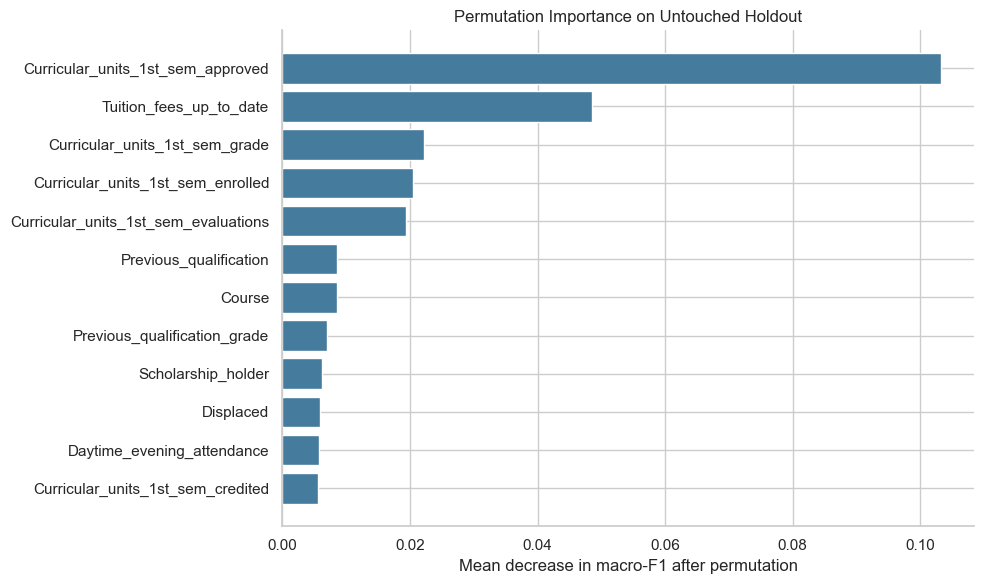

,factor,group,student_count,actual_dropout_count,recall,false_positive_rate,precision,small_group_flag
0,GenderLabel,Female,570,139,87.8%,33.2%,46.0%,False
1,GenderLabel,Male,315,145,93.1%,45.9%,63.4%,False
2,AgeGroup,17-20,490,107,82.2%,27.4%,45.6%,False
3,AgeGroup,21-24,161,48,93.8%,49.6%,44.6%,False
4,AgeGroup,25-34,151,84,95.2%,58.2%,67.2%,False
5,AgeGroup,35+,83,45,97.8%,55.3%,67.7%,False
6,InternationalLabel,No,861,275,90.5%,36.7%,53.7%,False
7,InternationalLabel,Yes,24,9,88.9%,40.0%,57.1%,True


In [19]:
importance_result = permutation_importance(
    calibrated_model,
    X_test_selected,
    y_test,
    scoring="f1_macro",
    n_repeats=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std,
}).sort_values("importance_mean", ascending=False)
importance_df.to_csv(IMPORTANCE_PATH, index=False)
display(importance_df.style.format({
    "importance_mean": "{:.4f}", "importance_std": "{:.4f}"
}))

top_importance = importance_df.head(12).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_importance["feature"], top_importance["importance_mean"], color="#457B9D")
ax.set(
    title="Permutation Importance on Untouched Holdout",
    xlabel="Mean decrease in macro-F1 after permutation",
    ylabel="",
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

test_context = prepared_df.iloc[test_index][
    ["GenderLabel", "AgeGroup", "InternationalLabel"]
].copy()
test_context["actual_dropout"] = y_test_binary
test_context["dropout_alert"] = test_alert
subgroup_rows = []
for factor in ["GenderLabel", "AgeGroup", "InternationalLabel"]:
    for group, group_data in test_context.groupby(factor, observed=False):
        group_cm = confusion_matrix(
            group_data["actual_dropout"], group_data["dropout_alert"], labels=[0, 1]
        )
        group_tn, group_fp, group_fn, group_tp = group_cm.ravel()
        subgroup_rows.append({
            "factor": factor,
            "group": str(group),
            "student_count": len(group_data),
            "actual_dropout_count": int(group_data["actual_dropout"].sum()),
            "recall": group_tp / (group_tp + group_fn) if group_tp + group_fn else np.nan,
            "false_positive_rate": group_fp / (group_fp + group_tn) if group_fp + group_tn else np.nan,
            "precision": group_tp / (group_tp + group_fp) if group_tp + group_fp else np.nan,
            "small_group_flag": len(group_data) < 50,
        })
subgroup_audit = pd.DataFrame(subgroup_rows)
subgroup_audit.to_csv(SUBGROUP_PATH, index=False)
display(subgroup_audit.style.format({
    "recall": "{:.1%}", "false_positive_rate": "{:.1%}", "precision": "{:.1%}"
}))

Subgroup audit bersifat diagnostik dan beberapa kelompok berukuran kecil.
Perbedaan metrik tidak boleh dianggap stabil tanpa data tambahan. Sebelum
penggunaan operasional, institusi perlu menetapkan batas minimum sample,
memonitor drift, dan mengaudit kembali recall serta false-positive rate.

## 12. Export Model dan Deployment Contract

In [20]:
final_model = clone(calibrated_template)
final_model.fit(X_all[selected_features], y_all)

categorical_features = [
    column for column in selected_features if column in categorical_candidates
]
numeric_features = [
    column for column in selected_features if column not in categorical_features
]
input_options = {
    column: sorted(int(value) for value in df[column].unique())
    for column in categorical_features
}
input_defaults = {
    column: (
        int(df[column].mode().iloc[0]) if column in categorical_features
        else float(df[column].median())
    )
    for column in selected_features
}
input_ranges = {
    column: {"minimum": float(df[column].min()), "maximum": float(df[column].max())}
    for column in numeric_features
}

artifact = {
    "model": final_model,
    "model_name": best_model_name,
    "checkpoint": best_checkpoint,
    "feature_columns": list(selected_features),
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "class_order": list(final_model.classes_),
    "dropout_threshold": dropout_threshold,
    "input_options": input_options,
    "input_defaults": input_defaults,
    "input_ranges": input_ranges,
    "intended_use": "Prioritize supportive student outreach with human review",
    "prohibited_use": "No punitive, exclusionary, or fully automated academic decisions",
}
joblib.dump(artifact, MODEL_PATH)

model_metadata = {
    key: value for key, value in artifact.items() if key != "model"
}
model_metadata.update({
    "training_rows_final": len(df),
    "development_rows": len(train_index),
    "holdout_rows_used_for_evaluation": len(test_index),
    "holdout_metrics": holdout_metrics,
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
})
with METADATA_PATH.open("w", encoding="utf-8") as handle:
    json.dump(model_metadata, handle, indent=2)

prediction_sample = df[selected_features].sample(5, random_state=RANDOM_STATE)
prediction_sample.to_csv(PREDICTION_SAMPLE_PATH, index=False)

reloaded_artifact = joblib.load(MODEL_PATH)
reloaded_probabilities = reloaded_artifact["model"].predict_proba(prediction_sample)
assert reloaded_probabilities.shape == (5, 3)
assert np.allclose(reloaded_probabilities.sum(axis=1), 1.0)

print(f"Model artifact    : {MODEL_PATH}")
print(f"Metadata          : {METADATA_PATH}")
print(f"Prediction sample : {PREDICTION_SAMPLE_PATH}")
print(f"Feature count     : {len(selected_features)}")

Model artifact    : model\student_status_model.joblib
Metadata          : model\model_metadata.json
Prediction sample : data\prediction_sample.csv
Feature count     : 17


## 13. Status Phase 4

Model comparison, calibration, threshold tuning, untouched holdout
evaluation, permutation importance, subgroup audit, dan model export
telah dijalankan. Model final adalah pipeline lengkap agar preprocessing
yang sama selalu digunakan saat inferensi lokal maupun Streamlit.

## Model evaluation and interpretation

The selected operational model is a class-balanced random forest using the **first-semester monitoring checkpoint**. Selection used five-fold stratified cross-validation on the training partition only. The model deliberately excludes protected or sensitive identity attributes, family background, macroeconomic variables, and second-semester academic fields.

On the untouched 20% holdout set (885 students), the calibrated three-class model achieved **0.720 accuracy**, **0.634 macro F1**, **0.630 balanced accuracy**, and **0.856 macro one-vs-rest ROC-AUC**. At the training-tuned dropout screening threshold of **0.147**, dropout recall was **0.905** and precision was **0.538**. This favors catching students who may need support, while accepting that staff must review false-positive alerts.

Permutation importance identified first-semester approved units, tuition-fee status, first-semester grade, enrolled units, and evaluations as the strongest operational predictors. These are associations for prioritizing outreach—not proof of causation and not grounds for punitive decisions.

## Deployment artifacts

The final pipeline, preprocessing logic, class calibration, input defaults, category options, and screening threshold are bundled in `model/student_status_model.joblib`. The Streamlit prototype in `app.py` loads this artifact, validates the 17 inputs, shows probabilities for Dropout/Enrolled/Graduate, and translates the screening result into supportive follow-up suggestions.

The Metabase dashboard uses `dashboard/student_dropout.db` as its analytical source. It separates descriptive student outcomes, key dropout factors, priority segments, and model quality indicators. The Metabase application database is exported as `metabase.db.mv.db` so the reviewer can restore the dashboard.

The Streamlit Community Cloud URL must be added to `README.md` after deployment. Dashboard screenshots must be saved as `reregin-dashboard.png`.

## Conclusion and recommended action items

Jaya Jaya Institut has a historical dropout rate of **32.1%** (1,421 of 4,424 students). The clearest actionable signals are unpaid tuition, very low first-semester approval, no approved first-semester units, debtor status, and several high-rate course segments.

1. Trigger a human-reviewed outreach workflow immediately after first-semester results, prioritizing students below the model threshold only for routine monitoring and reviewing all alerts before contact.
2. Offer confidential financial counseling, payment-plan information, and scholarship screening to students with tuition or debtor signals.
3. Provide academic advising and tutoring to students with no approved units or approval below 50%, coordinated with the relevant course team.
4. Track outreach, service uptake, and later outcomes; retrain only after outcome maturity and monitor recall, false-positive rate, calibration, and subgroup disparities.
5. Never use the score for sanctions, admission, tuition access, or automatic academic decisions. The prototype is decision support for beneficial intervention.